# Clustering of Acoustic Environments

## Dataset download & imports

Dataset: https://www.kaggle.com/datasets/chrisfilo/urbansound8k

In [19]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("chrisfilo/urbansound8k")

# print("Path to dataset files:", path)

In [ ]:

from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import seaborn as sns
import pandas as pd
import numpy as np
import os
import librosa
import IPython.display as ipd
from scipy.io import wavfile as wav
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn import metrics
from IPython.display import Audio
from datetime import datetime
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2
from sklearn.preprocessing import RobustScaler
from sklearn.covariance import MinCovDet
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA

import os
import numpy as np
import pandas as pdX
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import warnings

from pathlib import Path
from tqdm import tqdm

# Sklearn - preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Clustering algorithms
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

# Evaluation metrics
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

# Scipy for dendrogram
from scipy.cluster.hierarchy import dendrogram, linkage

import glob
import os
import librosa
import numpy as np
import pandas as pd
from scipy.stats import kurtosis, skew
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                              adjusted_rand_score, normalized_mutual_info_score,
                              silhouette_samples)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage

In [21]:
dataset_path = "./data/urbansound8k"
metadata = pd.read_csv(dataset_path + "/UrbanSound8K.csv")

In [22]:
# Helper: 2D scatter coloured by an integer array
def scatter2d(embedding, color_ids, title, class_names, ax, cmap='tab10', showlegend=True):
    unique = np.unique(color_ids)
    palette = plt.get_cmap(cmap)(np.linspace(0, 1, max(len(unique), 1)))
    for i, uid in enumerate(unique):
        mask = color_ids == uid
        lbl  = class_names[uid] if uid >= 0 and uid < len(class_names) else f'Cluster {uid}'
        ax.scatter(embedding[mask, 0], embedding[mask, 1],
                   s=8, alpha=0.6, color=palette[i], label=lbl)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Dim 1'); ax.set_ylabel('Dim 2')
    if showlegend:
        ax.legend(markerscale=3, fontsize=7, loc='best')

## Exploratory Data Analysis

### Dataset Details
- Total clips: 8,732 WAV files
- Predefined folds: 10
- Metadata file: UrbanSound8K.csv
- Target classes: 10 urban sound categories:
    - air_conditioner
    - car_horn
    - children_playing
    - dog_bark
    - drilling
    - engine_idling
    - gun_shot
    - jackhammer
    - siren
    - street_music

- Meta-Data File: UrbanSound8K.csv provides:
    - slice_file_name: Audio file name.
    - fold: Fold allocation (1-10).
    - classID & class: Numeric ID and name of the sound class.
    - start & end: Slice start and end times within the original recording.
    - salience: Rating of sound prominence (1 = foreground, 2 = background)
    - fsID: Freesound ID of the recording.

### Audio Signal Loading and Visualization: Librosa vs. Scipy

In [ ]:
metadata.head()

In [ ]:
ipd.Audio(f'{dataset_path}/fold{metadata.iloc[1, 5]}/' + metadata.iloc[1, 0])

In [ ]:
librosa_audio_data, librosa_sample_rate = librosa.load(f'{dataset_path}/fold{metadata.iloc[1, 5]}/' + metadata.iloc[1, 0], sr=22050)
# An important thing to know about librosa is librosa converts any stereo signal into mono by default.
print(librosa_sample_rate)
print(librosa_audio_data)

plt.figure(figsize=(12, 4))
plt.plot(librosa_audio_data)
plt.show()

In [ ]:
#scipy
wave_sample_rate, wave_audio = wav.read(f'{dataset_path}/fold{metadata.iloc[1, 5]}/' + metadata.iloc[1, 0])

print(wave_sample_rate)
print(wave_audio)

# Original audio with 2 channels
plt.figure(figsize=(12, 4))
plt.plot(wave_audio)
plt.show()

### Missing values & Duplicates

In [ ]:
missing = metadata.isna().sum()
missing_pct = (missing / len(metadata) * 100).round(2)
missing_tbl = pd.DataFrame({
    "missing_count": missing,
    "missing_%": missing_pct
}).sort_values(["missing_count", "missing_%"], ascending=False)

if (missing_tbl["missing_count"] > 0).any():
    display(missing_tbl[missing_tbl["missing_count"] > 0])
else:
    print("No missing values found.")

row_missing = metadata.isna().any(axis=1).sum()
print(f"Rows with at least one missing value: {row_missing:,} ({row_missing / len(metadata) * 100:.2f}%)\n")


dup_count = metadata.duplicated().sum()
print(f"Duplicates: {dup_count:,} ({dup_count / len(metadata) * 100:.2f}%)")

### Class Distribution

In [ ]:
# Lets see the distribution of classes
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
class_counts = metadata["class"].value_counts()

sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis", hue=class_counts.index)
plt.title("Distribution of Classes", fontweight="bold", size=14, pad=15)

for index, value in enumerate(class_counts.values):
    plt.text(index, value, str(value), ha="center", fontsize=12)

plt.xticks(rotation=90)

plt.subplot(1, 2, 2)
colors = sns.color_palette("viridis", len(class_counts))
plt.pie(class_counts, labels=class_counts.index, autopct="%.2f%%",
        colors=colors, startangle=90, textprops={"fontsize": 12})

center_circle = plt.Circle((0, 0), 0.3, fc="white")
plt.gca().add_artist(center_circle)
plt.title("Class Distribution in Percentage", fontweight="bold", size=14, pad=15)

plt.tight_layout()
plt.show()

### Counts

In [ ]:
# Metadata integrity checks
metadata_overview = pd.DataFrame({
    "dtype": metadata.dtypes.astype(str),
    "missing": metadata.isna().sum(),
    "unique": metadata.nunique()
}).sort_values(["missing", "unique"], ascending=[False, False])

# Add duration for EDA (seconds)
metadata = metadata.copy()
metadata["duration_sec"] = (metadata["end"] - metadata["start"]).round(3)

# Fold x class coverage heatmap
fold_class_counts = pd.crosstab(metadata["fold"], metadata["class"])
plt.figure(figsize=(14, 5))
sns.heatmap(fold_class_counts, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Fold vs Class Sample Counts")
plt.xlabel("Class")
plt.ylabel("Fold")
plt.tight_layout()
plt.show()



### Clip Durations

In [ ]:
# Duration distribution and per-class spread
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(metadata["duration_sec"], bins=30, kde=True, color="teal", ax=axes[0])
axes[0].set_title("Distribution of Clip Duration")
axes[0].set_xlabel("Duration (seconds)")
axes[0].set_ylabel("Count")

sns.boxplot(
    data=metadata,
    x="class",
    y="duration_sec",
    hue="class",
    dodge=False,
    legend=False,
    palette="tab10",
    ax=axes[1]
)
axes[1].set_title("Duration by Class")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Duration (seconds)")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

### Sample Rate Distribution

In [ ]:
audio_root = Path("data/urbansound8k")
wav_files = sorted(audio_root.glob("fold*/*.wav"))

records = []
for p in wav_files:
    records.append({
        "file": p.name,
        "fold": p.parent.name,
        "sr": librosa.get_samplerate(str(p))
    })

df_sr = pd.DataFrame(records)

sr_counts = df_sr["sr"].value_counts().sort_index()
print("Counts by sample rate:")
print(sr_counts)

plt.figure(figsize=(7, 4))
ax = sr_counts.plot(kind="bar", color="#2a9d8f")
ax.set_title("Sample Rate Distribution")
ax.set_xlabel("Sample rate (Hz)")
ax.set_ylabel("Number of clips")
ax.bar_label(ax.containers[0], padding=3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
pd.crosstab(df_sr["fold"], df_sr["sr"]).sort_index().plot(
    kind="bar", stacked=True, colormap="Set2"
)
plt.title("Sample Rate by Fold")
plt.xlabel("Fold")
plt.ylabel("Number of clips")
plt.tight_layout()
plt.show()

### Per-Class Signal Visualizations

Each plot uses one representative audio clip from every class for a side-by-side comparison.

In [ ]:
one_sound_per_class = (
    metadata.sort_values(["class", "fold", "slice_file_name"])
    .groupby("class", as_index=False)
    .first()
)
class_order = one_sound_per_class["class"].tolist()

class_audio_cache = {}
for _, row in one_sound_per_class.iterrows():
    audio_path = os.path.join(
        os.path.abspath(dataset_path),
        f"fold{row['fold']}",
        row["slice_file_name"]
    )
    y, sr = librosa.load(audio_path, sr=22050)
    class_audio_cache[row["class"]] = {"y": y, "sr": sr, "path": audio_path}
    
one_sound_per_class[["class", "fold", "slice_file_name"]]
    

#### Waveforms (One Sample per Class)

This grid shows waveform shape over time for one representative clip from each UrbanSound8K class.

In [ ]:
n_classes = len(class_order)
n_cols = 2
n_rows = int(np.ceil(n_classes / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 2.8 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, class_name in zip(axes, class_order):
    y = class_audio_cache[class_name]["y"]
    sr = class_audio_cache[class_name]["sr"]
    librosa.display.waveshow(y, sr=sr, ax=ax)
    ax.set_title(class_name)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")

for ax in axes[n_classes:]:
    ax.axis("off")

plt.suptitle("Waveforms: One Sample per Class", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


#### Mel-Frequency Cepstral Coefficients (One Sample per Class)

MFCC heatmaps are shown for one representative clip per class to compare timbral structure across classes.

In [ ]:
n_mfcc = 40
n_classes = len(class_order)
n_cols = 2
n_rows = int(np.ceil(n_classes / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.2 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, class_name in zip(axes, class_order):
    y = class_audio_cache[class_name]["y"]
    sr = class_audio_cache[class_name]["sr"]
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    librosa.display.specshow(mfccs, sr=sr, x_axis="time", ax=ax, cmap="viridis")
    ax.set_title(class_name)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("MFCC Coefficients")

for ax in axes[n_classes:]:
    ax.axis("off")

plt.suptitle("MFCCs: One Sample per Class", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# # Summarize each clip by mean MFCC over time -> shape: (n_samples, n_mfcc)
# X_mfcc = X.mean(axis=2)
# X_scaled = RobustScaler().fit_transform(X_mfcc)

# iso = IsolationForest(
#     n_estimators=300,
#     contamination=0.03,
# )
# is_outlier = iso.fit_predict(X_scaled) == -1
# outlier_score = -iso.score_samples(X_scaled)  # larger = more abnormal

# if "extracted_features_df" in globals() and len(extracted_features_df) == len(X_scaled):
#     class_values = extracted_features_df["class"].values
# else:
#     class_values = np.array(["unknown"] * len(X_scaled))

# results = pd.DataFrame({
#     "class": class_values,
#     "is_outlier": is_outlier,
#     "outlier_score": outlier_score
# })

# n_out = int(is_outlier.sum())
# print(f"Outliers: {n_out} / {len(results)} ({n_out / len(results) * 100:.2f}%)")

# display(
#     results[results["is_outlier"]]
#     .sort_values("outlier_score", ascending=False)
#     .head(20)
# )

# display(
#     (results.groupby("class")["is_outlier"].mean() * 100)
#     .sort_values(ascending=False)
#     .to_frame("outlier_rate_%")
# )

# pca = PCA(n_components=2)
# Z = pca.fit_transform(X_scaled)

# plt.figure(figsize=(7, 5))
# plt.scatter(
#     Z[:, 0],
#     Z[:, 1],
#     c=np.where(is_outlier, "red", "blue"),
#     s=10,
#     alpha=0.7
# )
# plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)")
# plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)")
# plt.show()

## Data Prep

In [5]:
N_MFCC = 20
N_FEATURES = 7

def features_extractor(file_name):
    audio, sr = librosa.load(file_name, sr=22050)

    mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=N_MFCC)

    # return mfccs
    
    mfccs_min = np.min(mfccs, axis=1)  
    mfccs_max = np.max(mfccs, axis=1)
    mfccs_median = np.median(mfccs, axis=1)
    mfccs_mean = np.mean(mfccs, axis=1)
    mfccs_variance = np.var(mfccs, axis=1)
    mfccs_skewness = skew(mfccs, axis=1)
    mfccs_kurtosis = kurtosis(mfccs, axis=1)

    return mfccs_min, mfccs_max, mfccs_median, mfccs_mean, mfccs_variance, mfccs_skewness, mfccs_kurtosis

In [6]:
extracted_features = []

for index_num, row in tqdm(metadata.iterrows(), total=metadata.shape[0]):
    file_name = os.path.join(os.path.abspath(dataset_path), 'fold' + str(row["fold"]) + '/', str(row["slice_file_name"]))
    final_class_labels = row["class"]
    
    try:
        data = features_extractor(file_name)
        if data is not None:
            extracted_features.append([data, final_class_labels])
            
    except Exception as e:
        print(f"Error processing {file_name}: {e}")
        
extracted_features_df = pd.DataFrame(extracted_features,columns=['feature','class'])

for idx, feature in enumerate(extracted_features_df['feature'].head()):
    print(f"Index {idx}: Type: {type(feature)}, Shape: {np.shape(feature)}")

extracted_features_df.head()

 41%|████      | 3553/8732 [01:36<02:09, 40.14it/s]c:\Users\Redward\.conda\envs\tf-2.10\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1323
  warnings.warn(
 95%|█████████▌| 8322/8732 [03:35<00:08, 47.38it/s]c:\Users\Redward\.conda\envs\tf-2.10\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1103
  warnings.warn(
 95%|█████████▌| 8328/8732 [03:35<00:08, 49.28it/s]c:\Users\Redward\.conda\envs\tf-2.10\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1523
  warnings.warn(
100%|██████████| 8732/8732 [03:45<00:00, 38.71it/s]


Index 0: Type: <class 'tuple'>, Shape: (7, 20)
Index 1: Type: <class 'tuple'>, Shape: (7, 20)
Index 2: Type: <class 'tuple'>, Shape: (7, 20)
Index 3: Type: <class 'tuple'>, Shape: (7, 20)
Index 4: Type: <class 'tuple'>, Shape: (7, 20)


,feature,class
0,"([-423.43994, 30.75272, -145.28049, -79.04863,...",dog_bark
1,"([-486.05615, 73.074295, -79.079346, 27.764057...",children_playing
2,"([-492.76328, 91.19204, -59.20176, 2.5833035, ...",children_playing
3,"([-449.77115, 45.53283, -60.297638, 8.230274, ...",children_playing
4,"([-469.3726, 84.42387, -62.84462, 27.151588, -...",children_playing


In [7]:
# Initialize lists to store features and labels with consistent length
features = []
labels = []
label_names = []

for _, row in extracted_features_df.iterrows():
    f = row['feature']
    if f:
        # Pad or trim each feature to the target length
        # padded_feature = np.pad(f, ((0, 0), (0, max(0, target_length - f.shape[1]))), mode='constant')[:, :target_length]
        feature = np.concatenate([arr.flatten() for arr in f])
        
        features.append(feature)
        labels.append(row['class'])
        label_names.append(row['class'])


X = np.array(features)
y = np.array(labels)
y_raw = LabelEncoder().fit_transform(y)
y = to_categorical(LabelEncoder().fit_transform(y))

scaler = StandardScaler()
X = scaler.fit_transform(X)
print(f'Scaled feature matrix: mean≈{X.mean():.4f}, std≈{X.std():.4f}')

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("Label names:", label_names)
CLASS_NAMES = sorted(set(label_names))


Scaled feature matrix: mean≈0.0000, std≈1.0000
Shape of X: (8732, 140)
Shape of y: (8732, 10)
Label names: ['dog_bark', 'children_playing', 'children_playing', 'children_playing', 'children_playing', 'children_playing', 'children_playing', 'children_playing', 'children_playing', 'car_horn', 'car_horn', 'car_horn', 'car_horn', 'car_horn', 'dog_bark', 'dog_bark', 'dog_bark', 'dog_bark', 'dog_bark', 'dog_bark', 'dog_bark', 'dog_bark', 'air_conditioner', 'air_conditioner', 'air_conditioner', 'air_conditioner', 'air_conditioner', 'air_conditioner', 'air_conditioner', 'air_conditioner', 'air_conditioner', 'air_conditioner', 'air_conditioner', 'air_conditioner', 'air_conditioner', 'air_conditioner', 'air_conditioner', 'air_conditioner', 'air_conditioner', 'air_conditioner', 'air_conditioner', 'air_conditioner', 'air_conditioner', 'air_conditioner', 'air_conditioner', 'air_conditioner', 'air_conditioner', 'air_conditioner', 'air_conditioner', 'air_conditioner', 'air_conditioner', 'air_conditio

PCA(2) explained variance ratio: 0.281
t-SNE done.


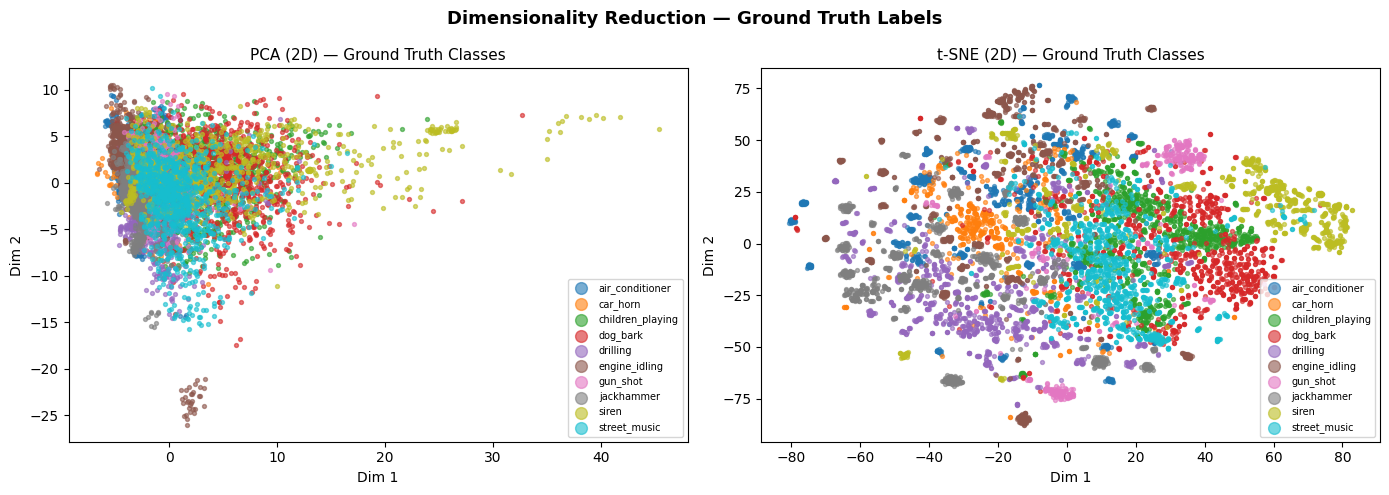

In [8]:
pca_2   = PCA(n_components=2)
X_pca2  = pca_2.fit_transform(X)
print(f'PCA(2) explained variance ratio: {pca_2.explained_variance_ratio_.sum():.3f}')


tsne  = TSNE(n_components=2, perplexity=50, n_iter_without_progress=1000)
X_tsne = tsne.fit_transform(X)
print('t-SNE done.')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
scatter2d(X_pca2,  np.argmax(y, axis=1), 'PCA (2D) — Ground Truth Classes', CLASS_NAMES, axes[0])
scatter2d(X_tsne,  np.argmax(y, axis=1), 't-SNE (2D) — Ground Truth Classes', CLASS_NAMES, axes[1])
plt.suptitle('Dimensionality Reduction — Ground Truth Labels', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Clustering

In [9]:
from sklearn.svm import SVC

x_train, x_test, y_train, y_test = train_test_split(X, y_raw, test_size=0.2)

clf = SVC(C = 1, kernel = 'rbf')
clf.fit(x_train, y_train)

print("Train Accuracy :", clf.score(x_train, y_train))
print('Test Accuracy :', clf.score(x_test, y_test))

Train Accuracy : 0.9199713672154617
Test Accuracy : 0.8717801946193474


Elbow / Silhouette sweep: 100%|██████████| 18/18 [00:24<00:00,  1.36s/it]


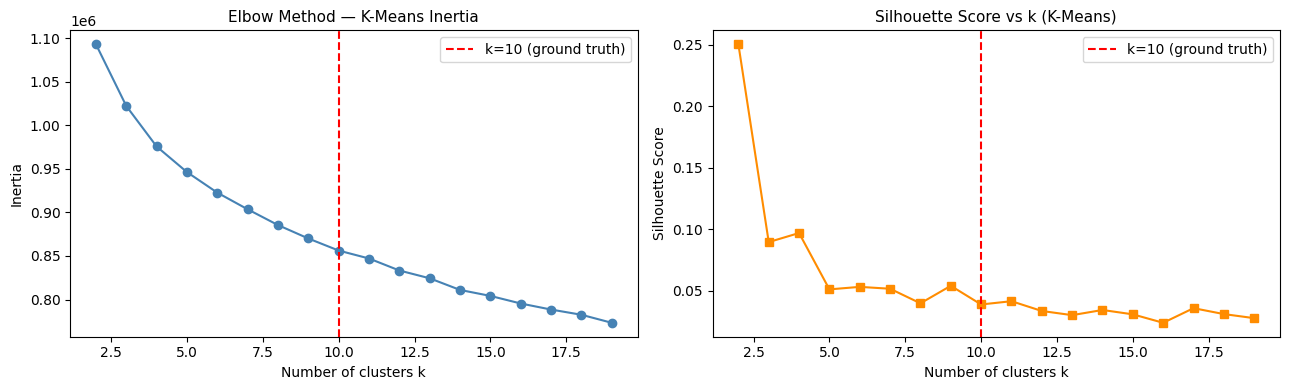

Best k by silhouette: 2  |  Using k=10 (matches ground-truth classes)


In [10]:
K_RANGE = range(2, 20)
inertias, sil_scores_km = [], []

for k in tqdm(K_RANGE, desc='Elbow / Silhouette sweep'):
    km = KMeans(n_clusters=k, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil_scores_km.append(silhouette_score(X, labels, sample_size=3000))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(list(K_RANGE), inertias, 'o-', color='steelblue')
axes[0].set_title('Elbow Method — K-Means Inertia', fontsize=11)
axes[0].set_xlabel('Number of clusters k'); axes[0].set_ylabel('Inertia')
axes[0].axvline(10, color='red', linestyle='--', label='k=10 (ground truth)')
axes[0].legend()

axes[1].plot(list(K_RANGE), sil_scores_km, 's-', color='darkorange')
axes[1].set_title('Silhouette Score vs k (K-Means)', fontsize=11)
axes[1].set_xlabel('Number of clusters k'); axes[1].set_ylabel('Silhouette Score')
axes[1].axvline(10, color='red', linestyle='--', label='k=10 (ground truth)')
axes[1].legend()

plt.tight_layout()
plt.show()

best_k = list(K_RANGE)[np.argmax(sil_scores_km)]
print(f'Best k by silhouette: {best_k}  |  Using k=10 (matches ground-truth classes)')

K-Means (k=10)
  Inertia          : 854453.12
  Silhouette Score : 0.0476  (higher is better, range [-1, 1])
  Davies-Bouldin   : 2.3474  (lower is better)
  Adjusted Rand    : 0.1432  (1.0 = perfect match with ground truth)
  NMI              : 0.2629  (1.0 = perfect)


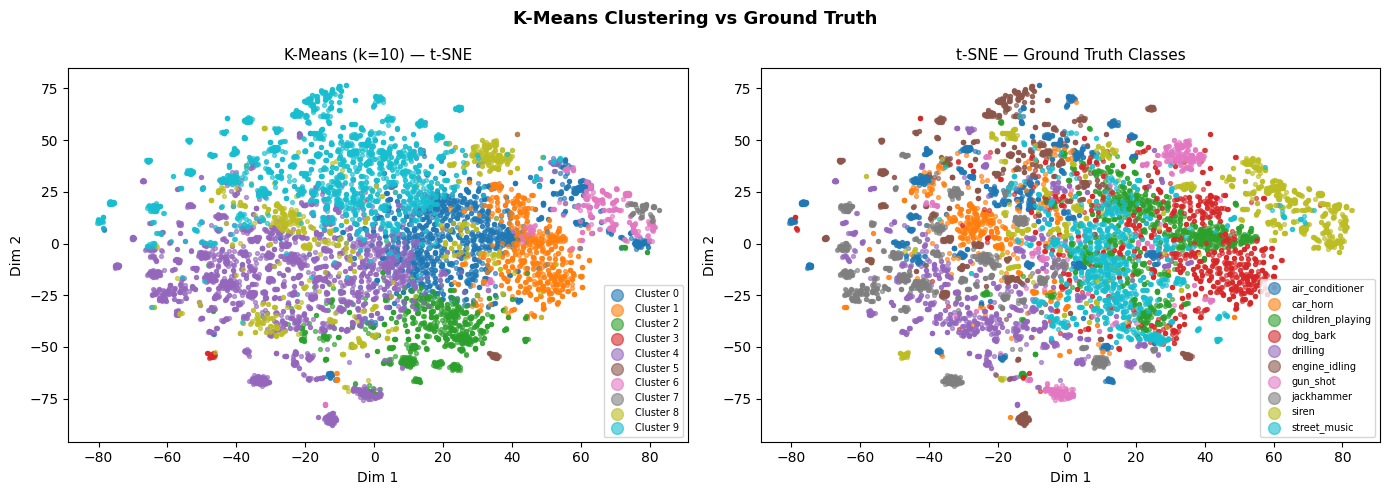

In [11]:
K = 10   # matches the 10 ground-truth classes

km_model = KMeans(n_clusters=K, n_init=20, max_iter=500)
km_labels = km_model.fit_predict(X)

sil_km  = silhouette_score(X, km_labels, sample_size=3000)
db_km   = davies_bouldin_score(X, km_labels)
ari_km  = adjusted_rand_score(label_names, km_labels)
nmi_km  = normalized_mutual_info_score(label_names, km_labels)

print(f'K-Means (k={K})')
print(f'  Inertia          : {km_model.inertia_:.2f}')
print(f'  Silhouette Score : {sil_km:.4f}  (higher is better, range [-1, 1])')
print(f'  Davies-Bouldin   : {db_km:.4f}  (lower is better)')
print(f'  Adjusted Rand    : {ari_km:.4f}  (1.0 = perfect match with ground truth)')
print(f'  NMI              : {nmi_km:.4f}  (1.0 = perfect)')


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
scatter2d(X_tsne, km_labels,  f'K-Means (k={K}) — t-SNE',         [f'Cluster {i}' for i in range(K)], axes[0])
scatter2d(X_tsne, np.argmax(y, axis=1),      't-SNE — Ground Truth Classes',      CLASS_NAMES,                         axes[1])
plt.suptitle('K-Means Clustering vs Ground Truth', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

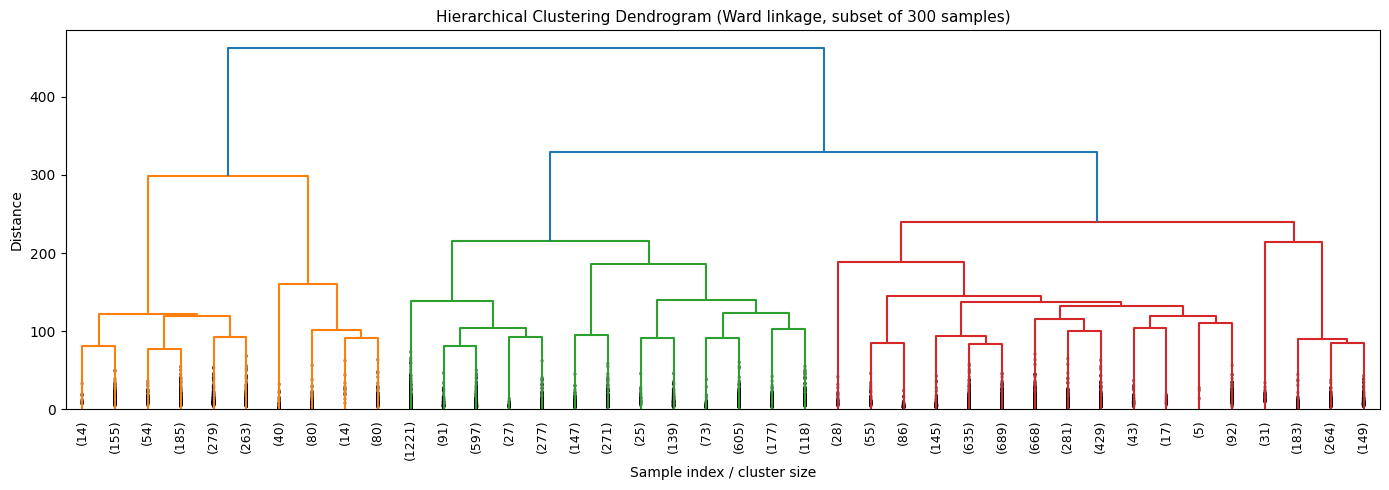

In [13]:
# subset_idx = np.random.choice(len(X), size=300, replace=False)
subset_idx = np.random.choice(len(X),size=8732, replace=False)
X_sub = X[subset_idx]

Z = linkage(X_sub, method='ward')

plt.figure(figsize=(14, 5))
dendrogram(Z, truncate_mode='lastp', p=40, leaf_rotation=90, leaf_font_size=9,
           show_contracted=True, color_threshold=None)
plt.title('Hierarchical Clustering Dendrogram (Ward linkage, subset of 300 samples)', fontsize=11)
plt.xlabel('Sample index / cluster size'); plt.ylabel('Distance')
plt.tight_layout()
plt.show()

Hierarchical Clustering (Ward, k=10)
  Silhouette Score : 0.0269
  Davies-Bouldin   : 2.4196
  Adjusted Rand    : 0.1265
  NMI              : 0.2639


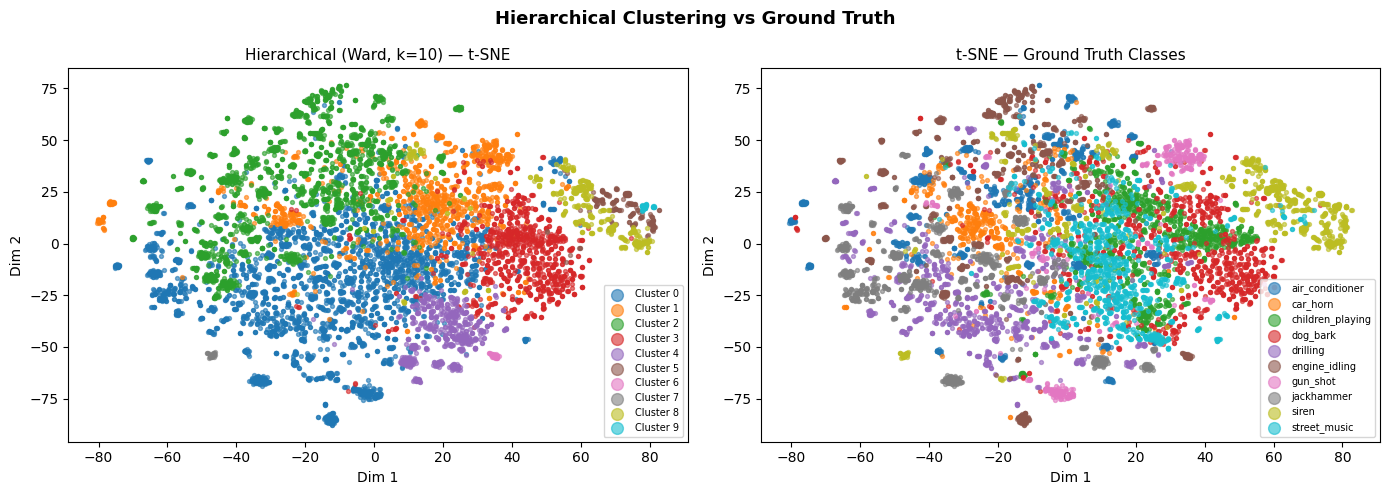

In [14]:
# Fit on full dataset
hc_model  = AgglomerativeClustering(n_clusters=K, linkage='ward')
hc_labels = hc_model.fit_predict(X)

sil_hc  = silhouette_score(X, hc_labels, sample_size=3000)
db_hc   = davies_bouldin_score(X, hc_labels)
ari_hc  = adjusted_rand_score(label_names, hc_labels)
nmi_hc  = normalized_mutual_info_score(label_names, hc_labels)

print(f'Hierarchical Clustering (Ward, k={K})')
print(f'  Silhouette Score : {sil_hc:.4f}')
print(f'  Davies-Bouldin   : {db_hc:.4f}')
print(f'  Adjusted Rand    : {ari_hc:.4f}')
print(f'  NMI              : {nmi_hc:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
scatter2d(X_tsne, hc_labels, f'Hierarchical (Ward, k={K}) — t-SNE', [f'Cluster {i}' for i in range(K)], axes[0])
scatter2d(X_tsne, np.argmax(y, axis=1),     't-SNE — Ground Truth Classes',         CLASS_NAMES,                         axes[1])
plt.suptitle('Hierarchical Clustering vs Ground Truth', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

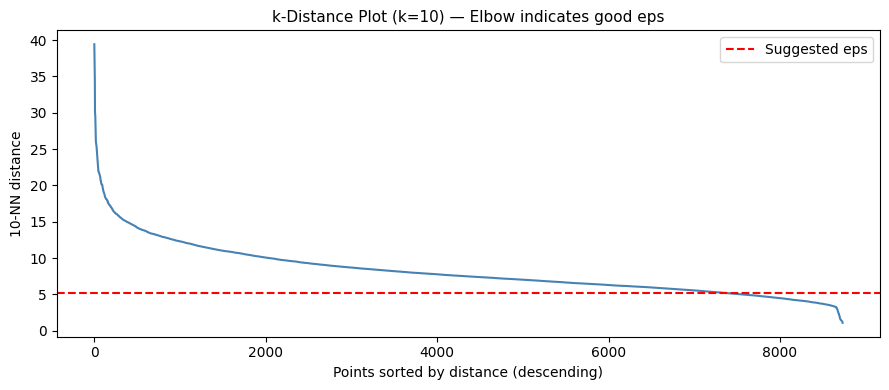

Suggested eps = 5.1418


In [15]:
from sklearn.neighbors import NearestNeighbors

# k-distance plot (k = min_samples - 1) to estimate eps
MIN_SAMPLES = 10
nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X)
distances, _ = nbrs.kneighbors(X)
k_distances   = np.sort(distances[:, -1])[::-1]

plt.figure(figsize=(9, 4))
plt.plot(k_distances, color='steelblue')
plt.title(f'k-Distance Plot (k={MIN_SAMPLES}) — Elbow indicates good eps', fontsize=11)
plt.xlabel('Points sorted by distance (descending)')
plt.ylabel(f'{MIN_SAMPLES}-NN distance')
plt.axhline(y=np.percentile(k_distances, 15), color='red', linestyle='--', label='Suggested eps')
plt.legend(); plt.tight_layout()
plt.show()

EPS = float(np.percentile(k_distances, 15))   # data-driven estimate
print(f'Suggested eps = {EPS:.4f}')

DBSCAN: eps=5.1418, min_samples=10
  Clusters found   : 57
  Noise points     : 6827 (78.2%)
  Silhouette Score : 0.2187
  Davies-Bouldin   : 1.3371
  Adjusted Rand    : 0.0541
  NMI              : 0.4301


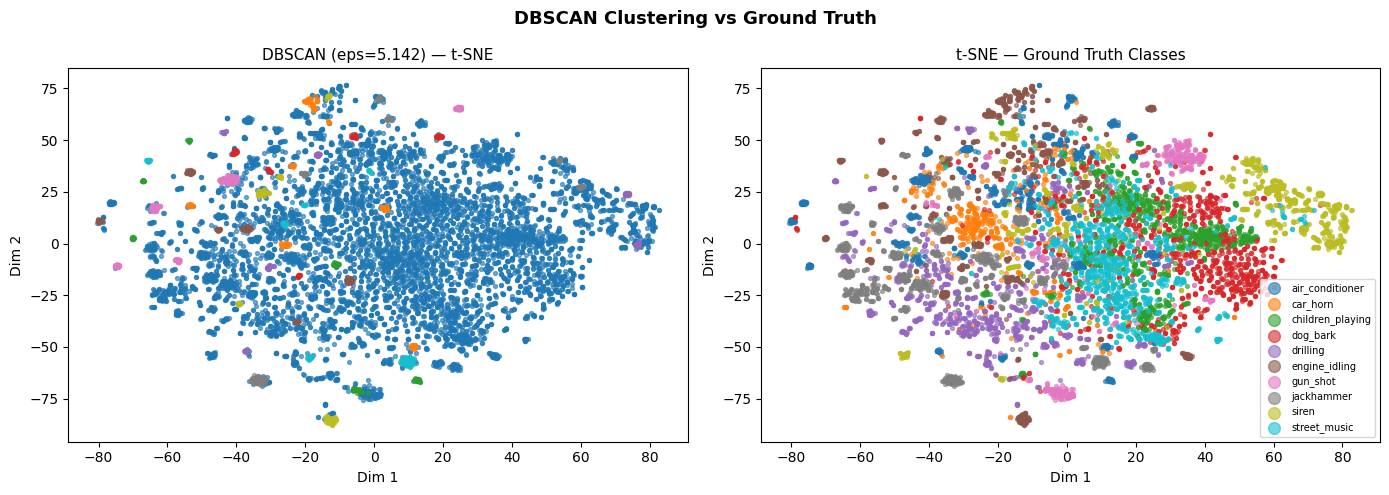

In [18]:
dbscan_model  = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES, n_jobs=-1)
db_scan_labels = dbscan_model.fit_predict(X)

n_clusters_db = len(set(db_scan_labels)) - (1 if -1 in db_scan_labels else 0)
n_noise       = np.sum(db_scan_labels == -1)
print(f'DBSCAN: eps={EPS:.4f}, min_samples={MIN_SAMPLES}')
print(f'  Clusters found   : {n_clusters_db}')
print(f'  Noise points     : {n_noise} ({100*n_noise/len(db_scan_labels):.1f}%)')

# Metrics only on non-noise points
mask_non_noise = db_scan_labels != -1
if n_clusters_db >= 2:
    sil_db  = silhouette_score(X[mask_non_noise], db_scan_labels[mask_non_noise], sample_size=3000)
    db_db   = davies_bouldin_score(X[mask_non_noise], db_scan_labels[mask_non_noise])
    ari_db  = adjusted_rand_score(np.argmax(y[mask_non_noise], axis=1), db_scan_labels[mask_non_noise])
    nmi_db  = normalized_mutual_info_score(np.argmax(y[mask_non_noise], axis=1), db_scan_labels[mask_non_noise])
    print(f'  Silhouette Score : {sil_db:.4f}')
    print(f'  Davies-Bouldin   : {db_db:.4f}')
    print(f'  Adjusted Rand    : {ari_db:.4f}')
    print(f'  NMI              : {nmi_db:.4f}')
else:
    sil_db = db_db = ari_db = nmi_db = float('nan')
    print('  Too few clusters for metrics — try adjusting eps or min_samples.')
    
    
    
# Map -1 (noise) to a distinct colour
db_plot_labels = db_scan_labels.copy()
unique_db      = sorted(set(db_plot_labels))
db_names       = [f'Noise' if u == -1 else f'Cluster {u}' for u in unique_db]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
scatter2d(X_tsne, db_plot_labels, f'DBSCAN (eps={EPS:.3f}) — t-SNE', db_names, axes[0], showlegend=False)
scatter2d(X_tsne, np.argmax(y, axis=1),     't-SNE — Ground Truth Classes',         CLASS_NAMES,                         axes[1])
plt.suptitle('DBSCAN Clustering vs Ground Truth', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Supplementary Analysis

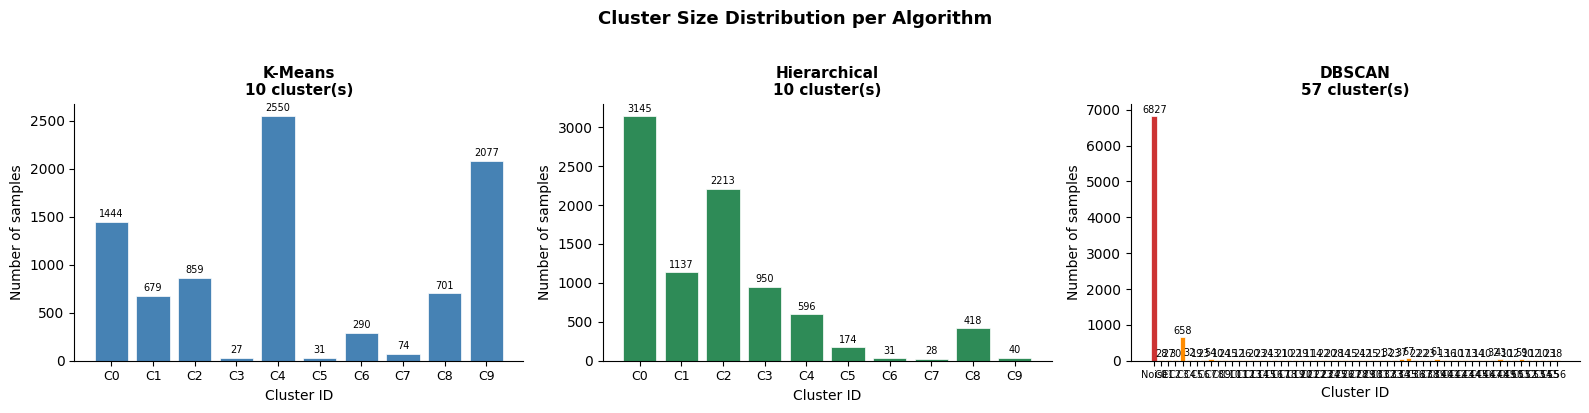

In [ ]:
# Cluster size bar charts
algo_info = [
    ('K-Means',      km_labels,       'steelblue'),
    ('Hierarchical', hc_labels,       'seagreen'),
    ('DBSCAN',       db_scan_labels,  'darkorange'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, labels, color) in zip(axes, algo_info):
    unique, counts = np.unique(labels, return_counts=True)
    tick_labels   = ['Noise' if u == -1 else f'C{u}' for u in unique]
    bar_colors    = ['#cc3333' if u == -1 else color for u in unique]
    bars = ax.bar(tick_labels, counts, color=bar_colors, edgecolor='white', linewidth=0.5)

    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                str(cnt), ha='center', va='bottom', fontsize=7)

    n_clusters = len(unique) - (1 if -1 in unique else 0)
    ax.set_title(f'{name}\n{n_clusters} cluster(s)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Cluster ID')
    ax.set_ylabel('Number of samples')
    ax.tick_params(axis='x', labelsize=7 if len(unique) > 15 else 9)
    sns.despine(ax=ax)

plt.suptitle('Cluster Size Distribution per Algorithm', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

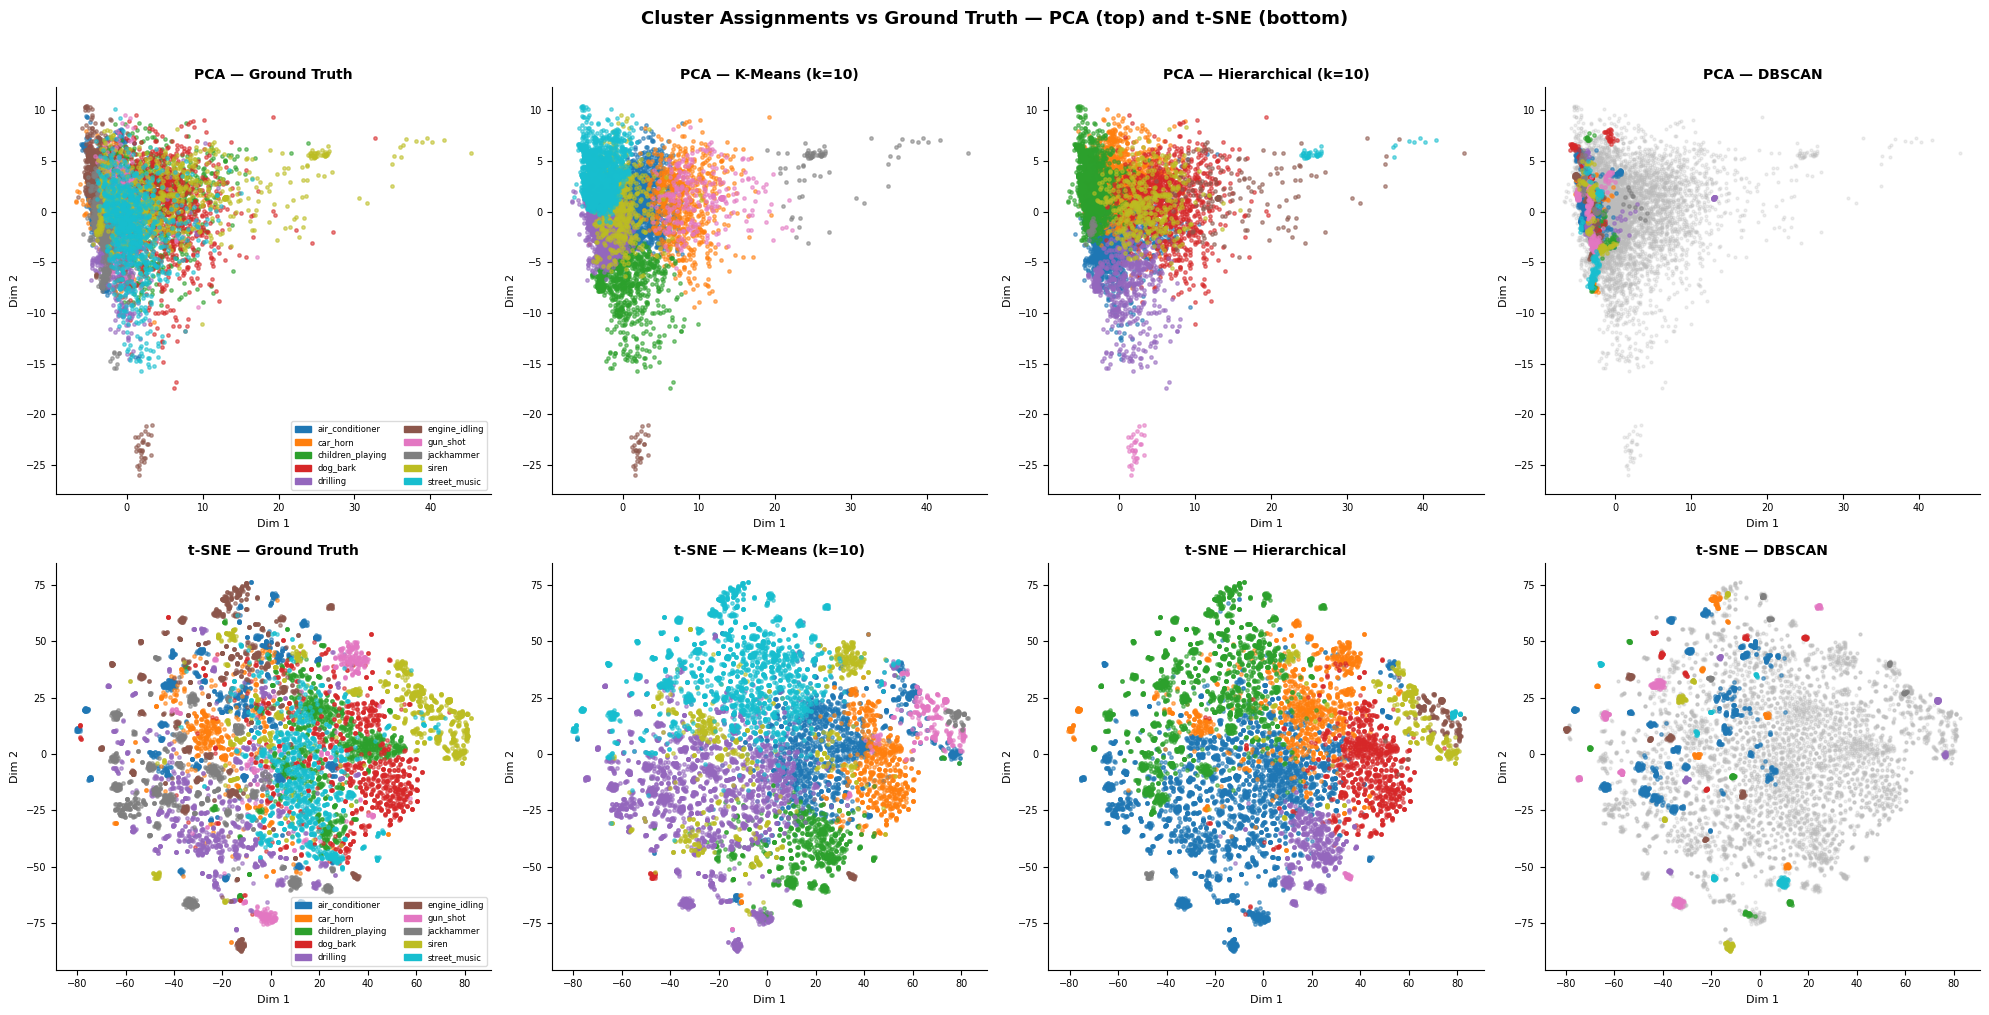

In [ ]:
CMAP        = plt.get_cmap('tab10')
NOISE_COLOR = '#bbbbbb'

def cluster_scatter(ax, embedding, labels, title, class_names=None,
                    show_legend=True, noise_label='Noise'):
    """Scatter plot coloured by cluster labels; noise points in grey."""
    unique = sorted(set(labels))
    n_real = len([u for u in unique if u != -1])
    palette = {u: (NOISE_COLOR if u == -1 else CMAP(i / max(n_real - 1, 1)))
               for i, u in enumerate([u for u in unique if u != -1])}
    if -1 in unique:
        palette[-1] = NOISE_COLOR

    handles = []
    for uid in unique:
        mask  = labels == uid
        color = palette[uid]
        if uid == -1:
            ax.scatter(embedding[mask, 0], embedding[mask, 1],
                       s=4, alpha=0.25, color=color, zorder=1)
            handles.append(mpatches.Patch(color=color, label=noise_label))
        else:
            lbl = (class_names[uid] if class_names and uid < len(class_names)
                   else f'Cluster {uid}')
            ax.scatter(embedding[mask, 0], embedding[mask, 1],
                       s=6, alpha=0.55, color=color, zorder=2, label=lbl)
            handles.append(mpatches.Patch(color=color, label=lbl))

    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Dim 1', fontsize=8); ax.set_ylabel('Dim 2', fontsize=8)
    ax.tick_params(labelsize=7)
    sns.despine(ax=ax)
    if show_legend and len(handles) <= 15:
        ax.legend(handles=handles, fontsize=6, markerscale=2,
                  loc='best', framealpha=0.7, ncol=2)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

gt_labels = np.array([CLASS_NAMES.index(l) for l in label_names])

plot_cfg = [
    # (embedding, labels, title, class_names_for_legend)
    (X_pca2,  gt_labels,      'PCA — Ground Truth',        CLASS_NAMES),
    (X_pca2,  km_labels,      'PCA — K-Means (k=10)',      None),
    (X_pca2,  hc_labels,      'PCA — Hierarchical (k=10)', None),
    (X_pca2,  db_scan_labels, 'PCA — DBSCAN',              None),
    (X_tsne,  gt_labels,      't-SNE — Ground Truth',      CLASS_NAMES),
    (X_tsne,  km_labels,      't-SNE — K-Means (k=10)',    None),
    (X_tsne,  hc_labels,      't-SNE — Hierarchical',      None),
    (X_tsne,  db_scan_labels, 't-SNE — DBSCAN',            None),
]

for ax, (emb, lbl, title, cnames) in zip(axes.flat, plot_cfg):
    cluster_scatter(ax, emb, lbl, title, class_names=cnames,
                    show_legend=(cnames is not None))

plt.suptitle('Cluster Assignments vs Ground Truth — PCA (top) and t-SNE (bottom)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

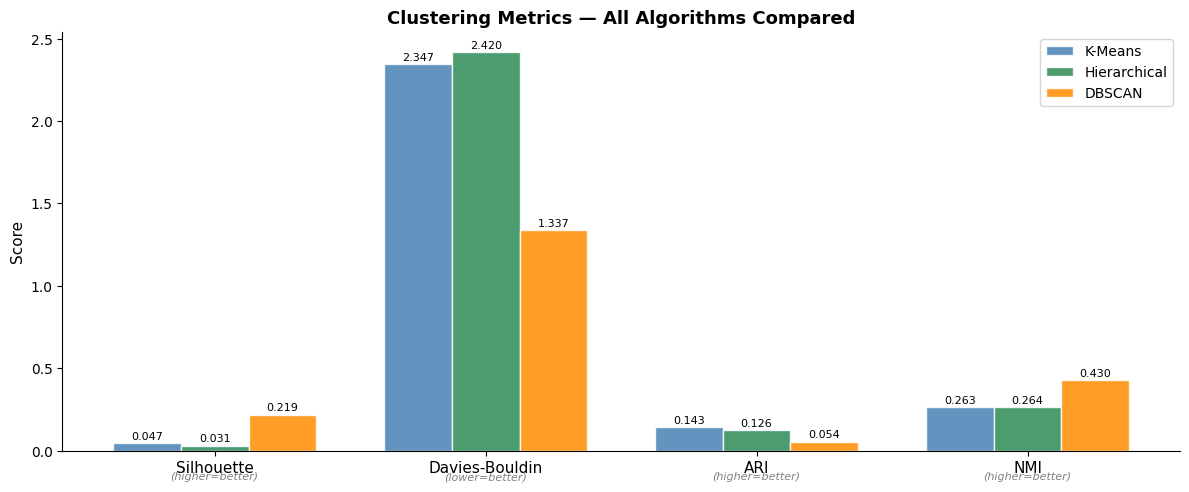

,Silhouette,Davies-Bouldin,ARI,NMI
K-Means,0.046700,2.347400,0.143200,0.262900
Hierarchical,0.031100,2.419600,0.126500,0.263900
DBSCAN,0.218700,1.337100,0.054100,0.430100


In [ ]:
# Collect metrics (uses values from your original notebook; re-compute here for safety)
mask_nn  = db_scan_labels != -1
n_db_cls = len(set(db_scan_labels)) - (1 if -1 in db_scan_labels else 0)

metrics_data = {
    'K-Means': {
        'Silhouette'      : silhouette_score(X, km_labels, sample_size=3000, random_state=42),
        'Davies-Bouldin'  : davies_bouldin_score(X, km_labels),
        'ARI'             : adjusted_rand_score(label_names, km_labels),
        'NMI'             : normalized_mutual_info_score(label_names, km_labels),
    },
    'Hierarchical': {
        'Silhouette'      : silhouette_score(X, hc_labels, sample_size=3000, random_state=42),
        'Davies-Bouldin'  : davies_bouldin_score(X, hc_labels),
        'ARI'             : adjusted_rand_score(label_names, hc_labels),
        'NMI'             : normalized_mutual_info_score(label_names, hc_labels),
    },
    'DBSCAN': {
        'Silhouette'      : silhouette_score(X[mask_nn], db_scan_labels[mask_nn], sample_size=3000, random_state=42) if n_db_cls >= 2 else np.nan,
        'Davies-Bouldin'  : davies_bouldin_score(X[mask_nn], db_scan_labels[mask_nn]) if n_db_cls >= 2 else np.nan,
        'ARI'             : adjusted_rand_score(np.array(label_names)[mask_nn], db_scan_labels[mask_nn]) if n_db_cls >= 2 else np.nan,
        'NMI'             : normalized_mutual_info_score(np.array(label_names)[mask_nn], db_scan_labels[mask_nn]) if n_db_cls >= 2 else np.nan,
    },
}

metric_names  = ['Silhouette', 'Davies-Bouldin', 'ARI', 'NMI']
algo_names    = list(metrics_data.keys())
colors        = ['steelblue', 'seagreen', 'darkorange']
x             = np.arange(len(metric_names))
width         = 0.25

fig, ax = plt.subplots(figsize=(12, 5))

for i, (algo, color) in enumerate(zip(algo_names, colors)):
    vals = [metrics_data[algo][m] for m in metric_names]
    bars = ax.bar(x + i*width, vals, width, label=algo, color=color, alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=8)

# Direction annotations
for xi, (metric, direction) in enumerate(zip(metric_names,
        ['higher=better', 'lower=better', 'higher=better', 'higher=better'])):
    ax.text(xi + width, -0.07, f'({direction})', ha='center', fontsize=8,
            color='grey', style='italic', transform=ax.get_xaxis_transform())

ax.set_xticks(x + width)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Clustering Metrics — All Algorithms Compared', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(0, color='black', linewidth=0.5)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

# Print the table too
metrics_df = pd.DataFrame(metrics_data).T.round(4)
display(metrics_df.style.highlight_max(subset=['Silhouette','ARI','NMI'], color='#d4edda')
                        .highlight_min(subset=['Davies-Bouldin'],         color='#d4edda')
                        .set_caption('Green = best value per metric'))

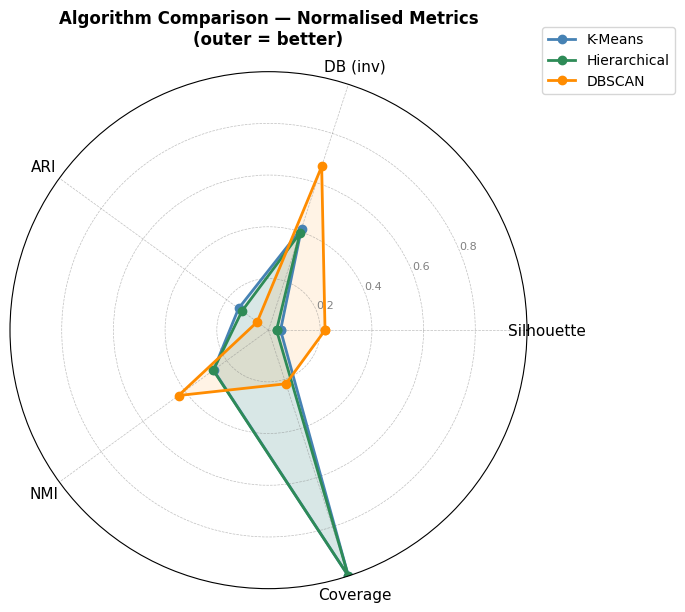

In [ ]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.ticker as mticker

# Normalise metrics to [0,1] where 1 is always best
# DB is inverted: score = 1 - (db / max_db)
# Coverage = 1 - noise_fraction
n_noise_db   = np.sum(db_scan_labels == -1)
coverage_db  = 1 - n_noise_db / len(db_scan_labels)

radar_metrics = {
    'K-Means'      : [metrics_data['K-Means']['Silhouette'],
                      1 - metrics_data['K-Means']['Davies-Bouldin'] / 4,
                      metrics_data['K-Means']['ARI'],
                      metrics_data['K-Means']['NMI'],
                      1.0],
    'Hierarchical' : [metrics_data['Hierarchical']['Silhouette'],
                      1 - metrics_data['Hierarchical']['Davies-Bouldin'] / 4,
                      metrics_data['Hierarchical']['ARI'],
                      metrics_data['Hierarchical']['NMI'],
                      1.0],
    'DBSCAN'       : [metrics_data['DBSCAN']['Silhouette'],
                      1 - metrics_data['DBSCAN']['Davies-Bouldin'] / 4,
                      metrics_data['DBSCAN']['ARI'],
                      metrics_data['DBSCAN']['NMI'],
                      coverage_db],
}
radar_labels = ['Silhouette', 'DB (inv)', 'ARI', 'NMI', 'Coverage']
N = len(radar_labels)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'polar': True})
algo_colors = {'K-Means': 'steelblue', 'Hierarchical': 'seagreen', 'DBSCAN': 'darkorange'}

for algo, vals in radar_metrics.items():
    v = vals + vals[:1]
    ax.plot(angles, v, 'o-', linewidth=2, label=algo, color=algo_colors[algo])
    ax.fill(angles, v, alpha=0.1, color=algo_colors[algo])

ax.set_thetagrids(np.degrees(angles[:-1]), radar_labels, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8])
ax.set_yticklabels(['0.2','0.4','0.6','0.8'], fontsize=8, color='grey')
ax.set_title('Algorithm Comparison — Normalised Metrics\n(outer = better)',
             fontsize=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()

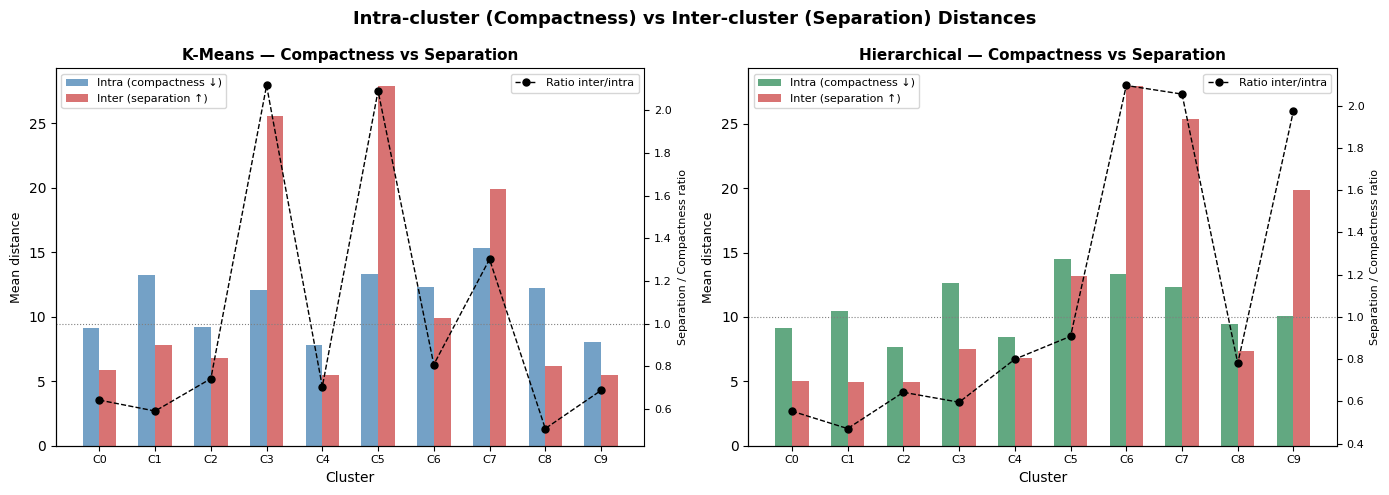

In [39]:
# ── CELL 3A — Intra-cluster (compactness) vs inter-cluster (separation) distances ────────────

def cluster_distances(X, labels):
    """Returns mean intra-cluster distance and mean nearest-cluster distance per cluster."""
    unique   = sorted(set(labels))
    centers  = {u: X[labels == u].mean(axis=0) for u in unique}
    intra    = {u: np.mean(np.linalg.norm(X[labels==u] - centers[u], axis=1)) for u in unique}
    inter    = {}
    for u in unique:
        dists = [np.linalg.norm(centers[u] - centers[v]) for v in unique if v != u]
        inter[u] = min(dists) if dists else 0
    return intra, inter

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, labels, color) in zip(axes, [('K-Means', km_labels, 'steelblue'),
                                             ('Hierarchical', hc_labels, 'seagreen')]):
    intra, inter = cluster_distances(X, labels)
    uids   = sorted(intra.keys())
    intra_v = [intra[u] for u in uids]
    inter_v = [inter[u] for u in uids]
    ratio_v = [b/a if a > 0 else 0 for a, b in zip(intra_v, inter_v)]

    x_pos = np.arange(len(uids))
    w     = 0.3
    ax.bar(x_pos - w/2, intra_v, w, label='Intra (compactness ↓)', color=color, alpha=0.75)
    ax.bar(x_pos + w/2, inter_v, w, label='Inter (separation ↑)',  color='#cc4444', alpha=0.75)

    ax2 = ax.twinx()
    ax2.plot(x_pos, ratio_v, 'ko--', markersize=5, linewidth=1, label='Ratio inter/intra')
    ax2.set_ylabel('Separation / Compactness ratio', fontsize=8, color='black')
    ax2.tick_params(labelsize=8)
    ax2.axhline(1, color='grey', linestyle=':', linewidth=0.8)

    ax.set_xticks(x_pos)
    ax.set_xticklabels([f'C{u}' for u in uids], fontsize=8)
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Mean distance', fontsize=9)
    ax.set_title(f'{name} — Compactness vs Separation', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, loc='upper left')
    ax2.legend(fontsize=8, loc='upper right')
    sns.despine(ax=ax)

plt.suptitle('Intra-cluster (Compactness) vs Inter-cluster (Separation) Distances',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

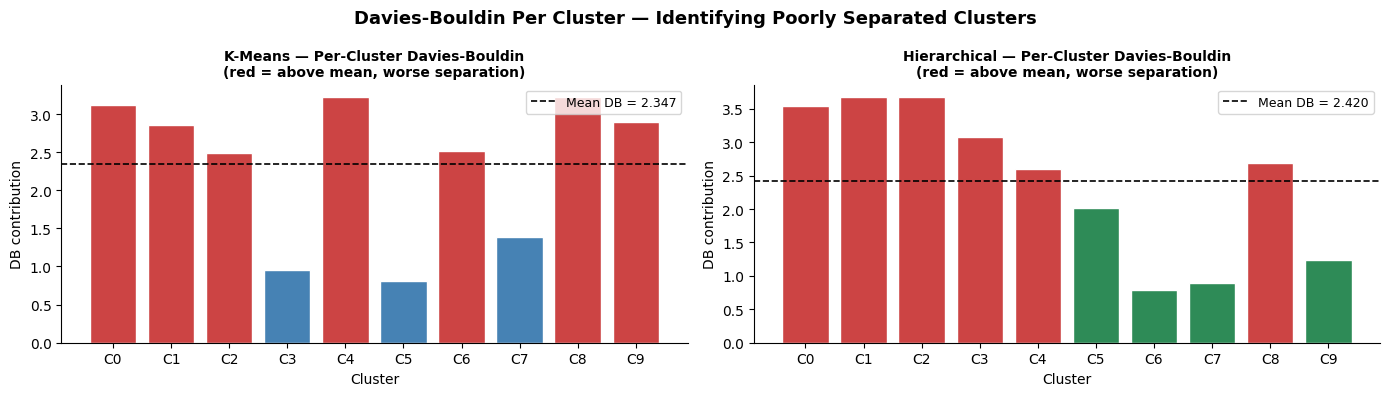

In [40]:
# ── CELL 3B — Davies-Bouldin per-cluster breakdown ───────────────────────────────────────────
# The DB index per cluster shows WHICH clusters are worst (highest DB = poorest separation).

def per_cluster_db(X, labels):
    """Compute the DB contribution per cluster (before taking the mean)."""
    unique  = sorted(set(labels))
    centers = {u: X[labels==u].mean(axis=0) for u in unique}
    scatter = {u: np.mean(np.linalg.norm(X[labels==u] - centers[u], axis=1)) for u in unique}
    db_per  = {}
    for i in unique:
        vals = [(scatter[i] + scatter[j]) / np.linalg.norm(centers[i] - centers[j])
                for j in unique if j != i]
        db_per[i] = max(vals) if vals else 0
    return db_per

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (name, labels, color) in zip(axes, [('K-Means', km_labels, 'steelblue'),
                                              ('Hierarchical', hc_labels, 'seagreen')]):
    db_per = per_cluster_db(X, labels)
    uids   = sorted(db_per.keys())
    vals   = [db_per[u] for u in uids]
    mean_  = np.mean(vals)

    bar_colors = ['#cc4444' if v > mean_ else color for v in vals]
    ax.bar([f'C{u}' for u in uids], vals, color=bar_colors, edgecolor='white')
    ax.axhline(mean_, color='black', linestyle='--', linewidth=1.2,
               label=f'Mean DB = {mean_:.3f}')
    ax.set_xlabel('Cluster'); ax.set_ylabel('DB contribution')
    ax.set_title(f'{name} — Per-Cluster Davies-Bouldin\n(red = above mean, worse separation)',
                 fontsize=10, fontweight='bold')
    ax.legend(fontsize=9)
    sns.despine(ax=ax)

plt.suptitle('Davies-Bouldin Per Cluster — Identifying Poorly Separated Clusters',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

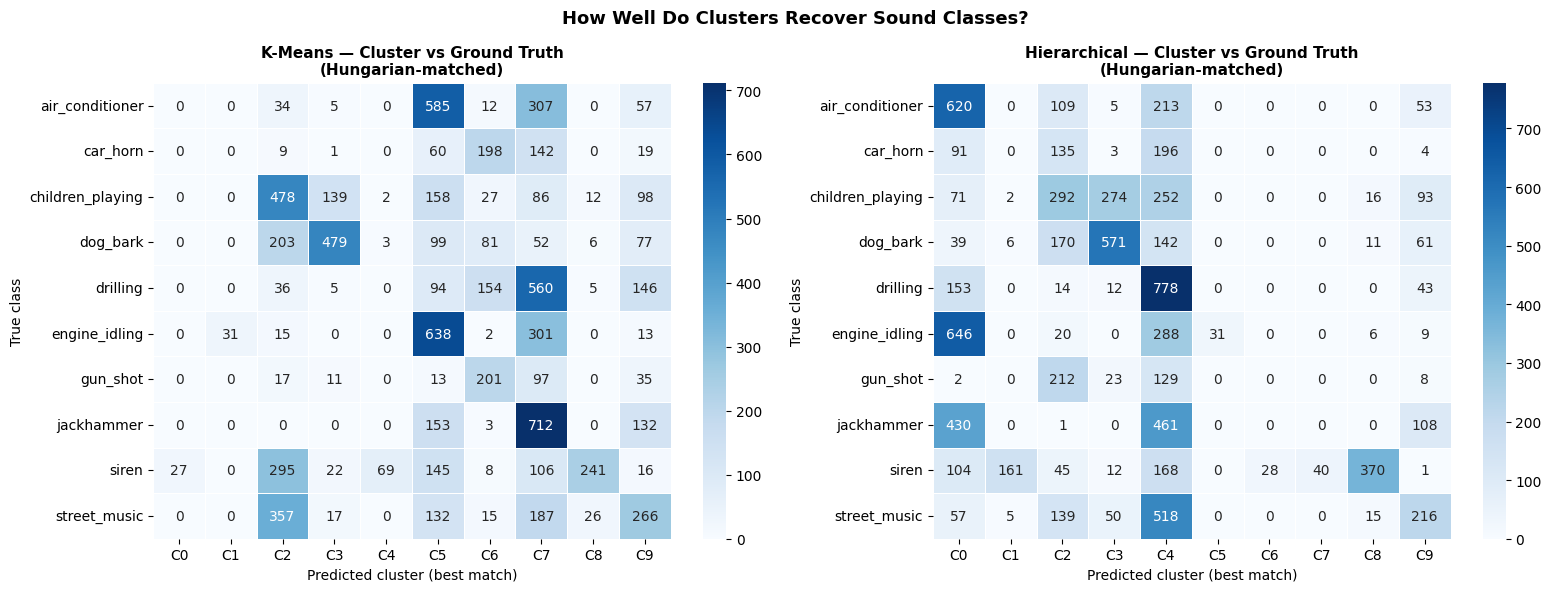

In [ ]:
# Shows how well each cluster aligns with true sound classes.
from sklearn.metrics import confusion_matrix
from scipy.optimize import linear_sum_assignment  # Hungarian algorithm for best label match

def best_match_confusion(true_labels, pred_labels, class_names):
    """Re-order predicted cluster IDs to maximally match ground truth using Hungarian algorithm."""
    le  = LabelEncoder()
    true_int = le.fit_transform(true_labels)
    K_   = len(class_names)
    cm   = confusion_matrix(true_int, pred_labels, labels=list(range(K_)))
    row_ind, col_ind = linear_sum_assignment(-cm)
    cm_reordered     = cm[:, col_ind]
    return cm_reordered, le.classes_

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (name, labels) in zip(axes, [('K-Means', km_labels), ('Hierarchical', hc_labels)]):
    cm_r, classes = best_match_confusion(label_names, labels, CLASS_NAMES)
    sns.heatmap(cm_r, annot=True, fmt='d', cmap='Blues',
                xticklabels=[f'C{i}' for i in range(K)],
                yticklabels=classes, ax=ax, linewidths=0.5)
    ax.set_xlabel('Predicted cluster (best match)', fontsize=10)
    ax.set_ylabel('True class', fontsize=10)
    ax.set_title(f'{name} — Cluster vs Ground Truth\n(Hungarian-matched)',
                 fontsize=11, fontweight='bold')

plt.suptitle('How Well Do Clusters Recover Sound Classes?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
summary = pd.DataFrame({
    'Metric / Property' : ['Silhouette', 'Davies-Bouldin', 'ARI', 'NMI',
                            'Clusters', 'Noise %', 'Stability', 'Scalability',
                            'Interpretability', 'Best use case'],
    'K-Means'           : [f"{metrics_data['K-Means']['Silhouette']:.4f}",
                            f"{metrics_data['K-Means']['Davies-Bouldin']:.4f}",
                            f"{metrics_data['K-Means']['ARI']:.4f}",
                            f"{metrics_data['K-Means']['NMI']:.4f}",
                            '10 (set)', '0%', 'Moderate', 'Fast O(nkd)',
                            'High — centroids', 'Class recovery & evaluation'],
    'Hierarchical'      : [f"{metrics_data['Hierarchical']['Silhouette']:.4f}",
                            f"{metrics_data['Hierarchical']['Davies-Bouldin']:.4f}",
                            f"{metrics_data['Hierarchical']['ARI']:.4f}",
                            f"{metrics_data['Hierarchical']['NMI']:.4f}",
                            '10 (set)', '0%', 'High — deterministic', 'Slow O(n²logn)',
                            'High — dendrogram', 'Hierarchy exploration'],
    'DBSCAN'            : [f"{metrics_data['DBSCAN']['Silhouette']:.4f} *",
                            f"{metrics_data['DBSCAN']['Davies-Bouldin']:.4f} *",
                            f"{metrics_data['DBSCAN']['ARI']:.4f} *",
                            f"{metrics_data['DBSCAN']['NMI']:.4f} *",
                            '57 (auto)',
                            f"{100*np.sum(db_scan_labels==-1)/len(db_scan_labels):.1f}%",
                            'Low — eps-sensitive', 'Moderate O(n logn)',
                            'Low — 57 clusters', 'Anomaly / outlier detection'],
}).set_index('Metric / Property')

display(summary.style
        .set_caption('* DBSCAN metrics computed on non-noise points only (21.8% of data)')
        .set_table_styles([{'selector': 'caption',
                             'props': [('font-size','11px'),('color','#666'),('font-style','italic')]}])
        .set_properties(**{'text-align': 'left', 'font-size': '12px'}))

print("\nVerdict: K-Means (k=10) is the recommended algorithm for this dataset.")
print("Reason : Best ARI (ground-truth alignment), full coverage, fast, interpretable.")
print("         DBSCAN finds denser sub-structure but cannot cluster 78% of the data.")

,K-Means,Hierarchical,DBSCAN
Metric / Property,,,
Silhouette,0.0467,0.0311,0.2187 *
Davies-Bouldin,2.3474,2.4196,1.3371 *
ARI,0.1432,0.1265,0.0541 *
NMI,0.2629,0.2639,0.4301 *
Clusters,10 (set),10 (set),57 (auto)
Noise %,0%,0%,78.2%
Stability,Moderate,High — deterministic,Low — eps-sensitive
Scalability,Fast O(nkd),Slow O(n²logn),Moderate O(n logn)
Interpretability,High — centroids,High — dendrogram,Low — 57 clusters



Verdict: K-Means (k=10) is the recommended algorithm for this dataset.
Reason : Best ARI (ground-truth alignment), full coverage, fast, interpretable.
         DBSCAN finds denser sub-structure but cannot cluster 78% of the data.
